In [44]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_unified as eu
import EI.ei_jax as ej
from EI.ei_utils import gap_info

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import plot_phase_diag, plot_energies_uv, plot_nalpha_beta, plot_nalpha_beta_bz

In [45]:
from utils.cosmetics import apply_plt_style, SET1_LIST
apply_plt_style()

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [46]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [47]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
m0 = s0.m
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"m_0     = {m0}")
logger.info(f"mu0     = {mu0}")
logger.info(f"T_c     = {tc}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[19:38:14] [INFO    ] Delta_0 = 1.0000516576515093
[19:38:14] [INFO    ] m_0     = -0.6843383516767371
[19:38:14] [INFO    ] mu0     = 3.2003407173280873
[19:38:14] [INFO    ] T_c     = 0.5352354225531222


In [48]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [20]:
bc = op["bath"]

rf = getattr(ej, bc["rate"])

bpars = dict(bc["pars"])
bpars["rate"] = rf

set mu_B = E_c

In [21]:
Ec = md["mean_field"]["v"] * md["mean_field"]["n"] /2 + (md["band"]["pars"]["ta"] + md["band"]["pars"]["tb"]) / (2 * (md["band"]["pars"]["ta"] - md["band"]["pars"]["tb"])) * (md["mean_field"]["v"] * s0.m - md["band"]["pars"]["gap"])
logger.info(f"E_c = {Ec}")

bpars["mu"] = Ec

[17:51:08] [INFO    ] E_c = 2.2


T2: 100%|██████████| 50/50 [05:31<00:00,  6.63s/it]


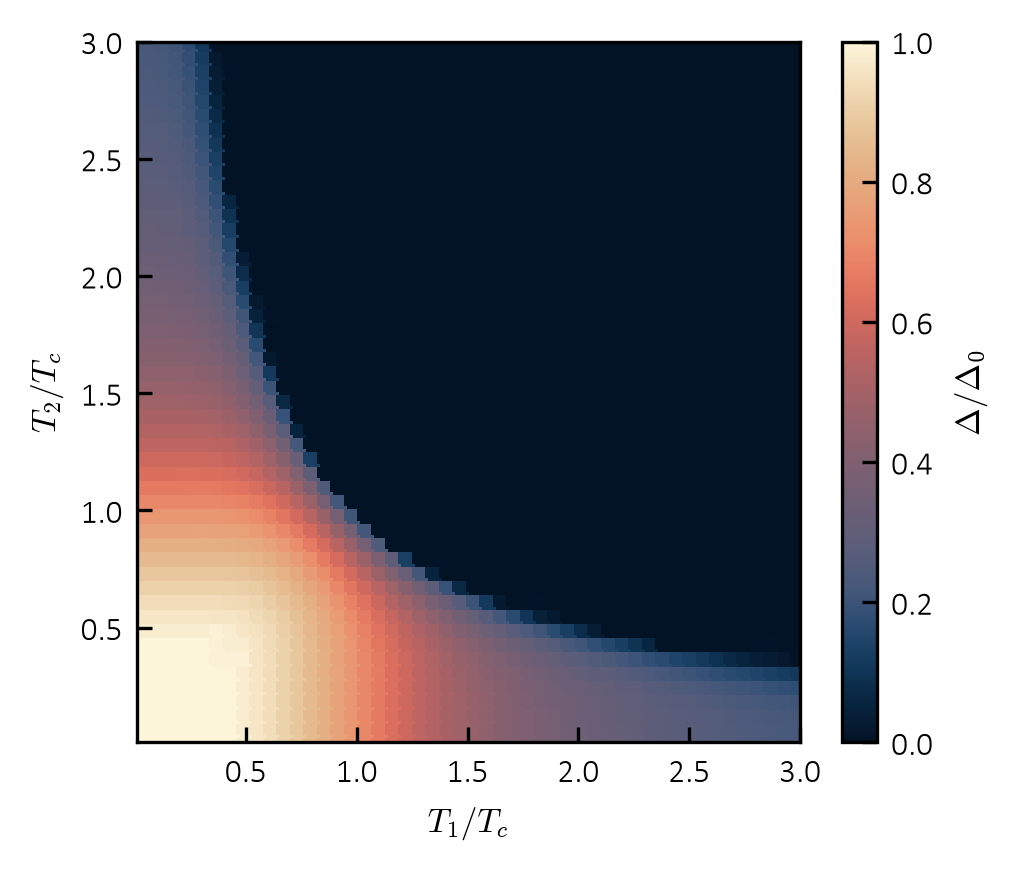

(<Figure size 347.412x295.3 with 2 Axes>,
 <Axes: xlabel='$T_1/T_c$', ylabel='$T_2/T_c$'>)

In [78]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

gh = np.full((nt, nt), np.nan)
gg = np.full((nt, nt), np.nan)
gd = np.full((nt, nt), np.nan)
gi = np.full((nt, nt), np.nan)


de = s0.d
me = s0.m
ds = 0.2 * max(d0, 1.0)

for j in tqdm(range(nt), desc="T2"):
    t2 = t2a[j]

    se = eu.solve_eq(
        bd, p, t=t2,
        d=max(abs(de), 1.0e-8),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1",
        leave=False,
    ):
        t1 = t1a[i]

        bs = (
            ej.gam_db(t=t1, name="bath 1", **bpars),
            ej.gam_db(t=t2, name="bath 2", **bpars),
        )

        so = ej.solve_open(
            bd, p, n, bs,
            d=d, m=m,
            **op["solve"],
        )

        ee = np.asarray(so.st.e)
        
        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        gp = gap_info(bd, so.st)

        gh[j, i] = gp["hartree_g"]
        gg[j, i] = gp["diag_g"]
        gd[j, i] = gp["diag_min"]
        gi[j, i] = gp["diag_ind"]

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

        gh[i, j] = gh[j, i]
        gg[i, j] = gg[j, i]
        gd[i, j] = gd[j, i]
        gi[i, j] = gi[j, i]

    de = se.d
    me = se.m

plot_phase_diag(da, d0, tn)

In [70]:
# st = ej.mf_state(bd, p, d=float(s0.d), m=float(s0.m))
# w = np.asarray(bd.w)
# nk = bd.size
# t1, t2 = 3.0 * tc, 0.2 * tc

# for wc in tqdm((np.inf, 1.0, 0.5), desc="Rate bandwidths"):
#     bp = {**bpars, "wc": wc, "rate": ej.rate_product}
#     bs = (ej.gam_db(t=t1, **bp), ej.gam_db(t=t2, **bp))
#     r = np.asarray(ej.dense_rates(st, bs))

#     rc = w @ r[:nk, nk:] @ w + w @ r[nk:, :nk] @ w
#     ri = w @ r[:nk, :nk] @ w + w @ r[nk:, nk:] @ w

#     print(f"wc={wc:4g}  inter={rc:.3e}  intra={ri:.3e}")

In [58]:
# t1, t2 = 3.0 * tc, 0.2 * tc
# d0 = s0.d
# ds = d0* np.array([0.01, 10.0])

# sh = eu.solve_eq(
#     bd, p, t=t1, d=0.1, m=-0.5,
#     **{**eq["solve"], "prog": False},
# )
# n0, m0 = sh.n.copy(), float(sh.m)

# bp = {**bpars, "wc": 0.5, "rate": ej.rate_product}
# bs = (
#     ej.gam_db(t=t1, name="bath 1", **bp),
#     ej.gam_db(t=t2, name="bath 2", **bp),
# )

# os = {
#     **op["solve"],
#     "mode": "dense",
#     "nmax": 100000,
#     "tol": 1e-5,
#     "prog": True,
#     "dt": 0.1,
# }

# curves = []
# for di in tqdm(ds, desc="Initial gaps"):
#     so = ej.solve_open(bd, p, n0.copy(), bs, d=float(di), m=m0, **os)

#     tt = np.r_[0.0, np.asarray(so.hist["t"])]
#     dd = np.r_[di, np.asarray(so.hist["d"])]
#     curves.append((tt, np.abs(dd) / d0, di / d0))

#     print(
#         f"d(0)/d0={di/d0:.2f}, d(end)/d0={abs(so.d)/d0:.4f}, "
#         f"time={so.time:.4g}, it={so.it}, err={so.err:.2e}"
#     )

In [59]:
# h = 0.85
# fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

# for i, (tt, dd, di) in tqdm(
#     enumerate(curves), total=len(curves), desc="Plotting trajectories"
# ):
#     ax.plot(
#         tt, dd, color=SET1_LIST[i], linewidth=1.3,
#         label=rf"$\Delta(0)/\Delta_0={di:.2f}$",
#     )

# ax.set_xlim(1e-20, max(tt[-1] for tt, _, _ in curves))
# ax.set_xlabel(r"$t$")
# ax.set_ylabel(r"$|\Delta(t)|/\Delta_0$")
# ax.grid(alpha=0.3)
# # ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend(
#     bbox_to_anchor=(0, 1.02, 1, 0.2),
#     loc="lower left", mode="expand",
#     borderaxespad=0, ncol=2,
# )
# plt.tight_layout()
# plt.show()

In [60]:
# Use the same point and rate parameters as the earlier trajectory.
t1 = 1.2 * tc
t2 = 0.5 * tc
wca = np.array([0.1, 0.3, 0.5, 0.8, 100.])
d0 = abs(s0.d)
x0 = 0.4

In [61]:
# # Recompute the hot equilibrium occupations on this band's k grid.
# se = eu.solve_eq(
#     bd, p, t=t1, d=1.0e-8 * d0, m=s0.m,
#     **eq["solve"],
# )
# ni = se.n.copy()
# mi = float(se.m)

# # Each call advances exactly one chunk. The next call receives its final state.
# ns = 2
# nstep = 10000
# kw = {
#     **op["solve"],
#     "nmax": ns,
#     "chk": ns,
#     "prog": False,
# }
# w = np.asarray(bd.w, dtype=float)
# out = []

# for wc in tqdm(wca, desc="Initial gaps"):
#     bp = {**bpars, "wc": wc}
#     bs = (
#         ej.gam_db(t=t1, name="bath 1", **bp),
#         ej.gam_db(t=t2, name="bath 2", **bp),
#     )

#     n = ni.copy()
#     d = float(x0)
#     m = mi
#     tt = 0.0

#     z = {
#         "t": [], "d": [], "m": [], "na": [],
#         "gn": [], "gs": [], "err": [], "cur": [],
#     }

#     for j in tqdm(
#         range(nstep // ns + 1),
#         desc=rf"$\Delta(0)/\Delta_0={wc:g}$"
#     ):
#         if j:
#             so = ej.solve_open(bd, p, n, bs, d=d, m=m, **kw)
#             n, d, m = so.n.copy(), float(so.d), float(so.m)
#             tt += float(so.hist["t"][-1])

#         st = ej.mf_state(bd, p, d=d, m=m)
#         tg = ej.targets(bd, p, st, n)

#         # This uses the same u*v evaluation as the solver.
#         gn = float(tg.d) / d if d != 0.0 else np.nan

#         # This evaluates u*v/d directly, avoiding 1 - xi/E cancellation.
#         xi = 0.5 * (
#             np.asarray(st.eah, dtype=float)
#             - np.asarray(st.ebh, dtype=float)
#         )
#         rr = np.hypot(xi, d)
#         gs = 0.5 * float(p.v) * np.sum(
#             w * (n[1] - n[0]) / rr
#         )

#         z["t"].append(tt)
#         z["d"].append(d)
#         z["m"].append(m)
#         z["na"].append(np.sum(w * n[0]))
#         z["gn"].append(gn)
#         z["gs"].append(gs)
#         z["err"].append(float(so.err) if j else np.nan)
#         z["cur"].append(
#             float(so.hist["cur"][-1]) if j else np.nan
#         )

#     out.append({k: np.asarray(v) for k, v in z.items()})

# # Reproduce the gap trajectory.
# h = 0.72
# fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

# for i in tqdm(range(len(out)), desc="Gap curves"):
#     z = out[i]
#     y = np.abs(z["d"]) / d0
#     ax.plot(
#         z["t"], np.where(y > 0.0, y, np.nan),
#         color=SET1_LIST[i], linewidth=1.3,
#         # label=rf"$\Delta(0)/\Delta_0={x0[i]:g}$",
#         label=rf"$w_c={wca[i]:g}$",
#     )

# # ax.set_yscale("log")
# ax.set_xlim(0.0, max(z["t"][-1] for z in out))
# ax.set_xlabel(r"$t$")
# ax.set_ylabel(r"$|\Delta(t)|/\Delta_0$")
# ax.grid(alpha=0.3)
# ax.legend(
# )
# plt.tight_layout()
# plt.show()

# # Plot diagnostics for the same trajectories.
# h = 1.65
# fig, ax = plt.subplots(
#     3, 1, sharex=True,
#     figsize=(3.47412, h * 3.47412),
# )

# for i in tqdm(range(len(out)), desc="Diagnostic curves"):
#     z = out[i]
#     c = SET1_LIST[i]

#     ax[0].plot(
#         z["t"], z["gn"], color=c, linewidth=1.1,
#         label=rf"$w_c={wca[i]:g}$",
#         # label=rf"$\Delta(0)/\Delta_0={x0[i]:g}$",
#     )
#     ax[0].plot(
#         z["t"], z["gs"], color=c,
#         linewidth=0.9, linestyle=":",
#     )
#     ax[1].plot(z["t"], z["na"], color=c, linewidth=1.1)
#     # ax[1].plot(z["t"], np.zeros_like(z["t"]), color="k", linewidth=0.1)
#     ax[2].plot(z["t"], z["m"], color=c, linewidth=1.1)

# ax[0].axhline(1.0, color="black", linestyle="--", linewidth=0.8)

# ax[0].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
# ax[1].set_ylabel(r"$\sum_k w_k n_{\alpha k}$")
# ax[2].set_ylabel(r"$m$")
# ax[2].set_xlabel(r"$t$")

# for q in tqdm(ax, desc="Format axes"):
#     q.set_xlim(0.0, max(z["t"][-1] for z in out))
#     q.grid(alpha=0.3)

# ax[0].legend(
# )
# plt.tight_layout()
# plt.show()

# # Report the minimum gap and the first sampled gain crossing after it.
# for i in tqdm(range(len(out)), desc="Onset checks"):
#     z = out[i]
#     j0 = int(np.argmin(np.abs(z["d"])))
#     q = np.flatnonzero(
#         (z["gs"][:-1] <= 1.0)
#         & (z["gs"][1:] > 1.0)
#         & (np.arange(z["gs"].size - 1) >= j0)
#     )

#     print(
#         f"seed={wca[i]:g}: "
#         f"min |d|/d0={abs(z['d'][j0])/d0:.3e} "
#         f"at t={z['t'][j0]:.1f}; "
#         f"max |gain difference|="
#         f"{np.nanmax(np.abs(z['gn'] - z['gs'])):.3e}"
#     )

#     if q.size:
#         j1 = int(q[0] + 1)
#         print(
#             f"  gain crosses 1 near t={z['t'][j1]:.1f}; "
#             f"Nalpha={z['na'][j1]:.6g}, "
#             f"m={z['m'][j1]:.6g}, "
#             f"err={z['err'][j1]:.3e}, "
#             f"current={z['cur'][j1]:.3e}"
#         )
#     else:
#         print("  No sampled gain crossing after the minimum")

Gap curves: 100%|██████████| 5/5 [00:00<00:00, 2959.99it/s]


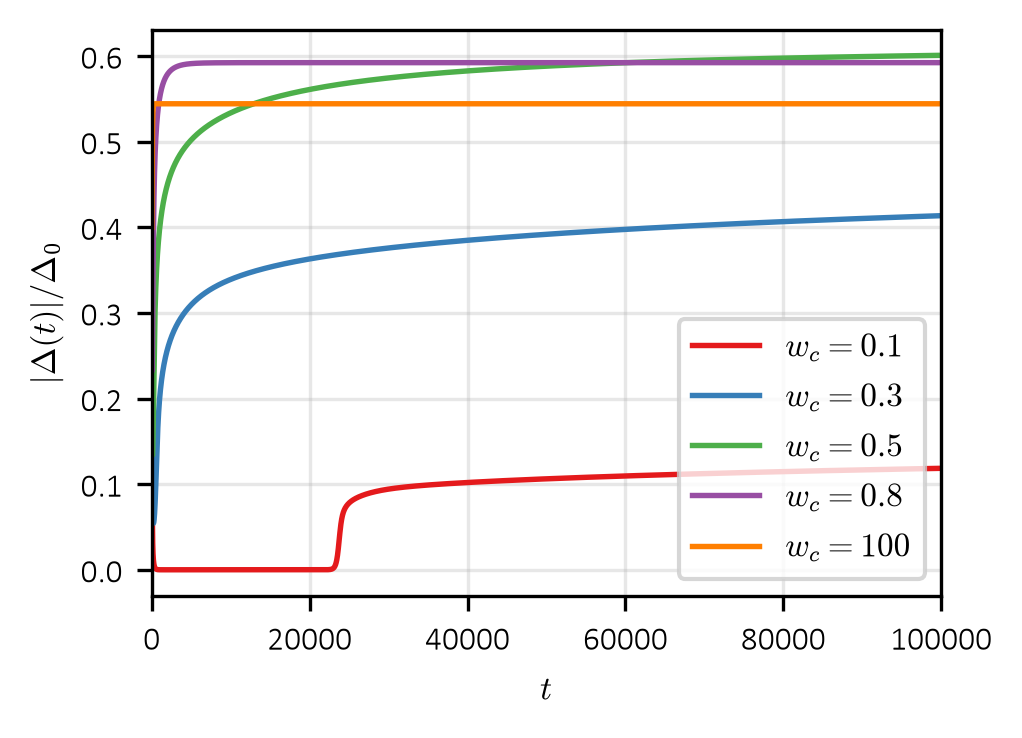

Format axes: 100%|██████████| 3/3 [00:00<00:00, 5368.14it/s]


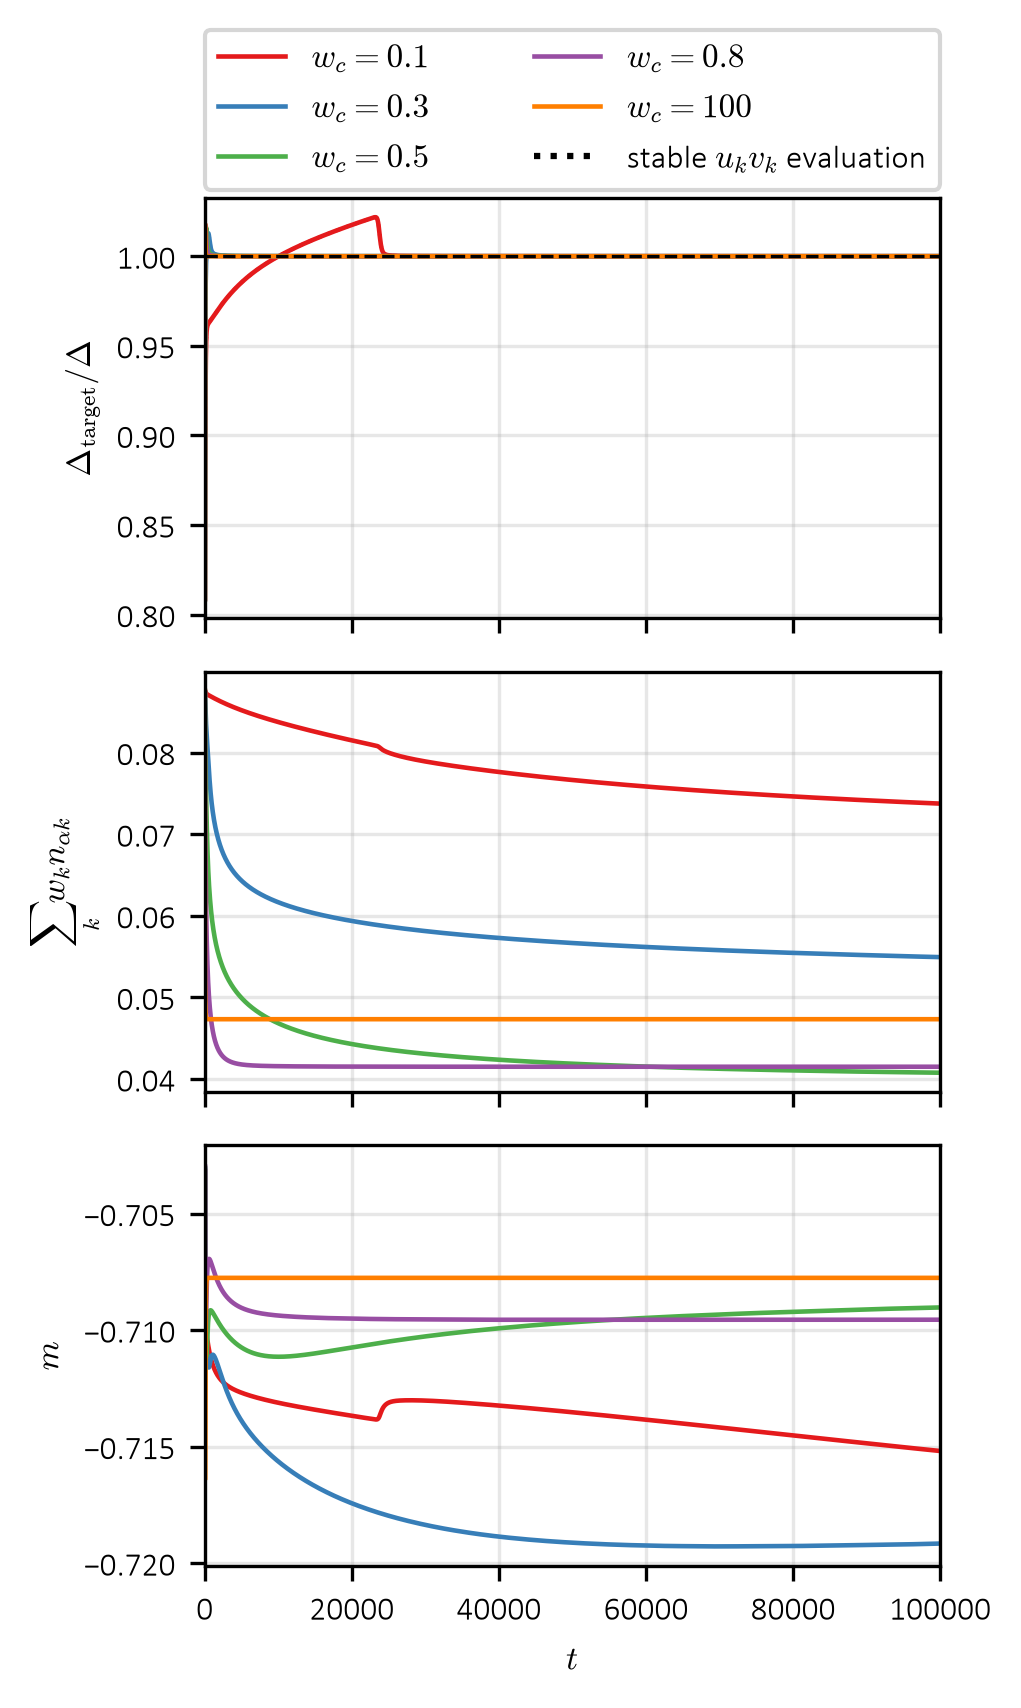

In [44]:
rate = getattr(ej, op["bath"]["rate"])
bpars = {**op["bath"]["pars"], "rate": rate}

se = eu.solve_eq(
    bd, p, t=t1, d=1.0e-8 * d0, m=s0.m,
    **eq["solve"],
)
ni = se.n.copy()
mi = float(se.m)

ns = int(op["solve"]["chk"])
nstep = int(op["solve"]["nmax"])
nc = (nstep + ns - 1) // ns

w = np.asarray(bd.w, dtype=float)
out = []

for wc in tqdm(wca, desc="Rate bandwidths"):
    bp = {**bpars, "wc": float(wc)}
    bs = (
        ej.gam_db(t=t1, name="bath 1", **bp),
        ej.gam_db(t=t2, name="bath 2", **bp),
    )

    n = ni.copy()
    d = float(x0)
    m = mi
    tt = 0.0

    z = {
        "t": [], "d": [], "m": [], "na": [],
        "gn": [], "gs": [], "err": [], "cur": [],
    }

    for j in tqdm(
        range(nc + 1),
        desc=rf"$w_c={wc:g}$",
        leave=False,
    ):
        if j:
            nq = min(ns, nstep - (j - 1) * ns)
            so = ej.solve_open(
                bd, p, n, bs, d=d, m=m,
                **{
                    **op["solve"],
                    "nmax": nq,
                    "chk": nq,
                },
            )
            n, d, m = so.n.copy(), float(so.d), float(so.m)
            tt += float(so.hist["t"][-1])

        st = ej.mf_state(bd, p, d=d, m=m)
        tg = ej.targets(bd, p, st, n)
        gn = float(tg.d) / d if d != 0.0 else np.nan

        xi = 0.5 * (
            np.asarray(st.eah, dtype=float)
            - np.asarray(st.ebh, dtype=float)
        )
        rr = np.hypot(xi, d)
        q = np.divide(
            np.asarray(n[1] - n[0], dtype=float),
            rr,
            out=np.zeros_like(rr),
            where=rr > 0.0,
        )
        gs = 0.5 * float(p.v) * np.sum(w * q) if d != 0.0 else np.nan

        z["t"].append(tt)
        z["d"].append(d)
        z["m"].append(m)
        z["na"].append(np.sum(w * n[0]))
        z["gn"].append(gn)
        z["gs"].append(gs)
        z["err"].append(float(so.err) if j else np.nan)
        z["cur"].append(
            float(so.hist["cur"][-1]) if j else np.nan
        )

    out.append({k: np.asarray(v) for k, v in z.items()})

h = 0.72
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

for i in tqdm(range(len(out)), desc="Gap curves"):
    z = out[i]
    y = np.abs(z["d"]) / d0
    ax.plot(
        z["t"], np.where(y > 0.0, y, np.nan),
        color=SET1_LIST[i], linewidth=1.3,
        label=rf"$w_c={wca[i]:g}$",
    )

ax.set_xlim(0.0, max(z["t"][-1] for z in out))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$|\Delta(t)|/\Delta_0$")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

h = 1.65
fig, ax = plt.subplots(
    3, 1, sharex=True,
    figsize=(3.47412, h * 3.47412),
)

for i in tqdm(range(len(out)), desc="Diagnostic curves"):
    z = out[i]
    c = SET1_LIST[i]

    ax[0].plot(
        z["t"], z["gn"], color=c, linewidth=1.1,
        label=rf"$w_c={wca[i]:g}$",
    )
    ax[0].plot(
        z["t"], z["gs"], color=c,
        linewidth=0.9, linestyle=":",
    )
    ax[1].plot(z["t"], z["na"], color=c, linewidth=1.1)
    ax[2].plot(z["t"], z["m"], color=c, linewidth=1.1)

ax[0].axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax[0].plot(
    [], [], color="black", linestyle=":",
    label=r"stable $u_kv_k$ evaluation",
)

ax[0].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
ax[1].set_ylabel(r"$\sum_k w_k n_{\alpha k}$")
ax[2].set_ylabel(r"$m$")
ax[2].set_xlabel(r"$t$")

xr = max(z["t"][-1] for z in out)
for axq in tqdm(ax, desc="Format axes"):
    axq.set_xlim(0.0, xr)
    axq.grid(alpha=0.3)

ax[0].legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left", mode="expand",
    borderaxespad=0, ncol=2,
)
plt.tight_layout()
plt.show()

In [9]:
t1, t2 = 0.9 * tc, 0.2 * tc
wc = 0.5
d0 = abs(s0.d)

sc = eu.solve_eq(
    bd, p, t=0.95*tc, d=max(d0, 1.0e-6), m=s0.m,
    **eq["solve"],
)
sh = eu.solve_eq(
    bd, p, t=2.0*tc, d=1.0e-8 * d0, m=s0.m,
    **eq["solve"],
)

bp = {**bpars, "wc": wc}
bs = (ej.gam_db(t=t1, **bp), ej.gam_db(t=t2, **bp))

ini = (
    ("cold ordered", sc.n.copy(), float(sc.d), float(sc.m)),
    ("hot normal", sh.n.copy(), 1.0e-2 * d0, float(sh.m)),
)

ns = 20
nstep = 30000
kw = {
    **op["solve"],
    "dt": 5.0,
    "prog": False,
}
mode = kw.get("mode", "dense")
block = kw.get("block", 512)
w = np.asarray(bd.w, dtype=float)
out = []

for lab, n0, di, mi in tqdm(ini, desc="Initial states"):
    n, d, m = n0.copy(), di, mi
    tt = 0.0
    z = {
        "t": [], "d": [], "m": [], "na": [],
        "gain": [], "j1": [], "j2": [],
        "cur": [], "ed": [], "em": [],
    }

    for j in tqdm(
        range(nstep // ns + 1), desc=lab, leave=False,
    ):
        if j:
            so = ej.solve_open(bd, p, n, bs, d=d, m=m, **kw)
            n, d, m = so.n.copy(), float(so.d), float(so.m)
            tt += float(so.hist["t"][-1])

        st = ej.mf_state(bd, p, d=d, m=m)
        tg = ej.targets(bd, p, st, n)

        c1 = np.asarray(ej.total_current(
            bd, st, n, (bs[0],), mode=mode, block=block,
        ))
        c2 = np.asarray(ej.total_current(
            bd, st, n, (bs[1],), mode=mode, block=block,
        ))

        z["t"].append(tt)
        z["d"].append(d)
        z["m"].append(m)
        z["na"].append(float(w @ np.asarray(n[0])))
        z["gain"].append(float(tg.d) / d if d != 0.0 else np.nan)
        z["j1"].append(float(w @ c1[0]))
        z["j2"].append(float(w @ c2[0]))
        z["cur"].append(float(np.max(np.abs(c1 + c2))))
        z["ed"].append(abs(float(tg.d) - d))
        z["em"].append(abs(float(tg.m) - m))

    out.append((lab, {k: np.asarray(v) for k, v in z.items()}))

h = 2.0
fig, ax = plt.subplots(
    5, 1, sharex=True,
    figsize=(3.47412, h * 3.47412),
)

for i in tqdm(range(len(out)), desc="Plot trajectories"):
    lab, z = out[i]
    c = SET1_LIST[i]
    y = np.abs(z["d"]) / d0

    ax[0].plot(
        z["t"], np.where(y > 0.0, y, np.nan),
        color=c, linewidth=1.2, label=lab,
    )
    ax[1].plot(z["t"], z["na"], color=c, linewidth=1.2)
    ax[2].plot(z["t"], z["m"], color=c, linewidth=1.2)
    ax[3].plot(z["t"], z["gain"], color=c, linewidth=1.2)
    ax[4].plot(
        z["t"], z["j1"], color=c, linewidth=1.1,
        label=f"{lab}, hot bath",
    )
    ax[4].plot(
        z["t"], z["j2"], color=c, linewidth=1.1,
        linestyle=":", label=f"{lab}, cold bath",
    )

ax[4].set_yscale("symlog", linthresh=1.0e-13)
ax[3].axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax[4].axhline(0.0, color="black", linestyle="--", linewidth=0.8)

ax[0].set_ylabel(r"$|\Delta|/\Delta_0$")
ax[1].set_ylabel(r"$N_\alpha$")
ax[2].set_ylabel(r"$m$")
ax[3].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
ax[4].set_ylabel(r"$\dot N_\alpha^{(\nu)}$")
ax[4].set_xlabel(r"$t$")

xr = max(z["t"][-1] for _, z in out)
for q in tqdm(ax, desc="Format axes"):
    q.set_xlim(0.0, xr)
    q.grid(alpha=0.3)

ax[0].legend()
ax[4].legend(
)
plt.tight_layout()
plt.show()

for lab, z in tqdm(out, desc="Endpoint checks"):
    print(
        f"{lab}: t={z['t'][-1]:.2f}, "
        f"d/d0={z['d'][-1]/d0:.6g}, "
        f"Nalpha={z['na'][0]:.6g}->{z['na'][-1]:.6g}, "
        f"gain={z['gain'][-1]:.6g}"
    )
    print(
        f"  initial bath currents: "
        f"{z['j1'][0]:.3e}, {z['j2'][0]:.3e}"
    )
    print(
        f"  final bath currents: "
        f"{z['j1'][-1]:.3e}, {z['j2'][-1]:.3e}; "
        f"max |I|={z['cur'][-1]:.3e}, "
        f"gap residual={z['ed'][-1]:.3e}, "
        f"m residual={z['em'][-1]:.3e}"
    )

Initial states:   0%|          | 0/2 [02:02<?, ?it/s]


KeyboardInterrupt: 

In [22]:
from collections import deque
from matplotlib.patches import Patch

d0 = abs(s0.d)
nr, nc = len(t2a), len(t1a)
w = np.asarray(bd.w, dtype=float)

# The reference state must be normal.
th = max(float(t1a[-1]), float(t2a[-1]), 1.5 * tc)
sh = eu.solve_eq(
    bd, p, t=th, d=1.0e-8 * d0, m=s0.m,
    **eq["solve"],
)
if abs(sh.d) > 1.0e-4 * d0:
    raise ValueError("The hot reference is ordered; increase th")

ds = 1.0e-3 * d0
ns = int(op["solve"]["chk"])

# These times exceed the delayed escape in the example shown.
tmin = 0.4e4
twin = 0.3e4
tmax = 3.0e4

# Use a stricter residual than the solver's usual stopping threshold.
etol = 0.1 * float(op["solve"]["tol"])
wtol = 2.0e-4

# The step cap also covers runs with some adaptive step reduction.
ncap = max(
    int(op["solve"]["nmax"]),
    int(np.ceil(2.0 * tmax / op["solve"]["dt"])),
)
nch = int(np.ceil(ncap / ns))

da = np.full((nr, nc), np.nan)
ma = np.full((nr, nc), np.nan)
er = np.full((nr, nc), np.nan)
ta = np.full((nr, nc), np.nan)
it = np.zeros((nr, nc), dtype=int)
ok = np.zeros((nr, nc), dtype=bool)

for j in range(nr - 1, -1, -1):
    t2 = float(t2a[j])

    for i in tqdm(
        range(nc - 1, -1, -1),
        desc=f"T1: hot to cold {[j]}"
    ):
        t1 = float(t1a[i])

        if i == nc - 1:
            # Right edge: continue from the right edge of the row above.
            if j < nr - 1 and ok[j + 1, i]:
                n, d, m = edge[0].copy(), edge[1], edge[2]
            else:
                n, d, m = sh.n.copy(), ds, float(sh.m)
        elif not ok[j, i + 1]:
            # Do not carry an unconverged state into the next point.
            n, d, m = sh.n.copy(), ds, float(sh.m)

        # Perturb a numerically normal parent only at the next grid point.
        if abs(d) < ds:
            d = ds

        bs = (
            ej.gam_db(t=t1, name="bath 1", **bpars),
            ej.gam_db(t=t2, name="bath 2", **bpars),
        )

        tt = 0.0
        ni = 0
        good = False
        buf = deque()
        err = np.inf

        for q in tqdm(range(nch), desc="Evolve", leave=False):
            nk0 = min(ns, ncap - q * ns)
            kw = {
                **op["solve"],
                "nmax": nk0,
                "chk": nk0,
                "prog": False,
            }

            so = ej.solve_open(bd, p, n, bs, d=d, m=m, **kw)

            n = so.n.copy()
            d = float(so.d)
            m = float(so.m)
            err = float(so.err)
            tt += float(so.hist["t"][-1])
            ni += int(so.it)

            na = float(w @ np.asarray(n[0]))
            buf.append((tt, abs(d) / d0, m, na))

            while len(buf) > 1 and buf[1][0] <= tt - twin:
                buf.popleft()

            if tt >= tmin and tt - buf[0][0] >= twin:
                a = np.asarray(buf)
                drift = float(np.max(np.ptp(a[:, 1:], axis=0)))

                if np.isfinite(err) and err < etol and drift < wtol:
                    good = True
                    break

            if tt >= tmax or not np.isfinite(err):
                break

        da[j, i] = abs(d)
        ma[j, i] = m
        er[j, i] = err
        ta[j, i] = tt
        it[j, i] = ni
        ok[j, i] = good

        if i == nc - 1:
            edge = (n.copy(), d, m)

print(f"Converged: {np.count_nonzero(ok)} / {ok.size}")
print(f"Nonconverged: {np.count_nonzero(~ok)}")

T1: hot to cold [0]: 100%|██████████| 10/10 [00:05<00:00,  1.76it/s]

Converged: 100 / 100
Nonconverged: 0


Plot maps:   0%|          | 0/2 [00:00<?, ?it/s]

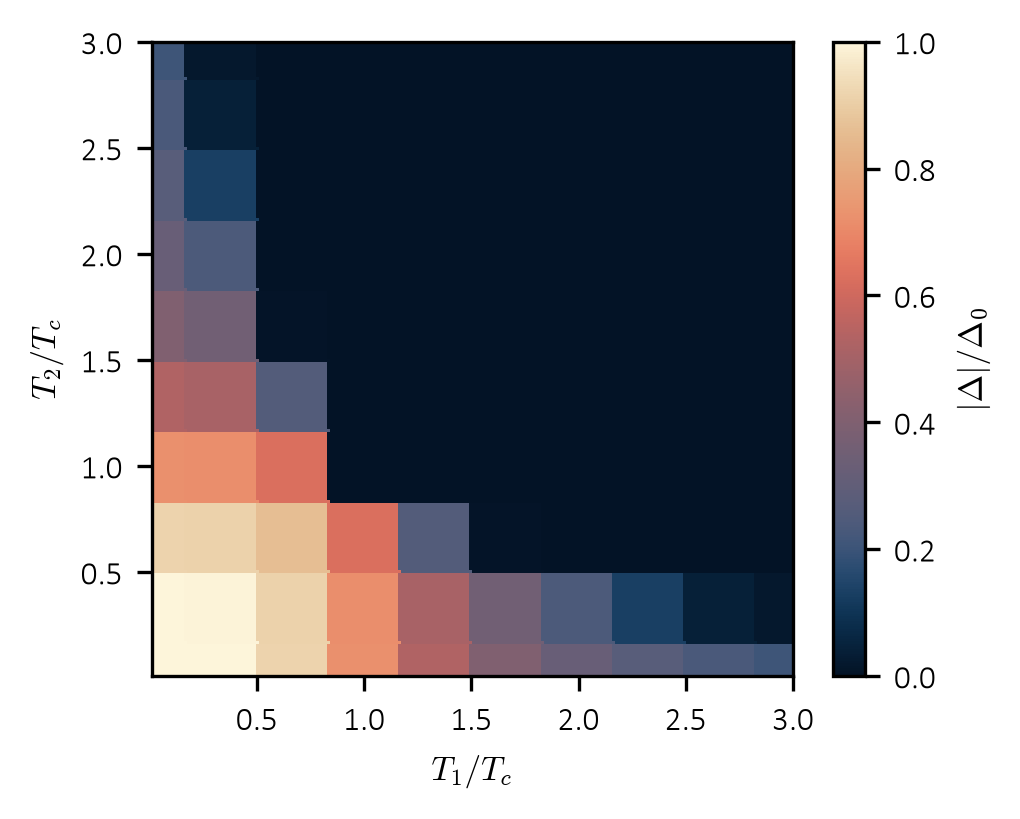

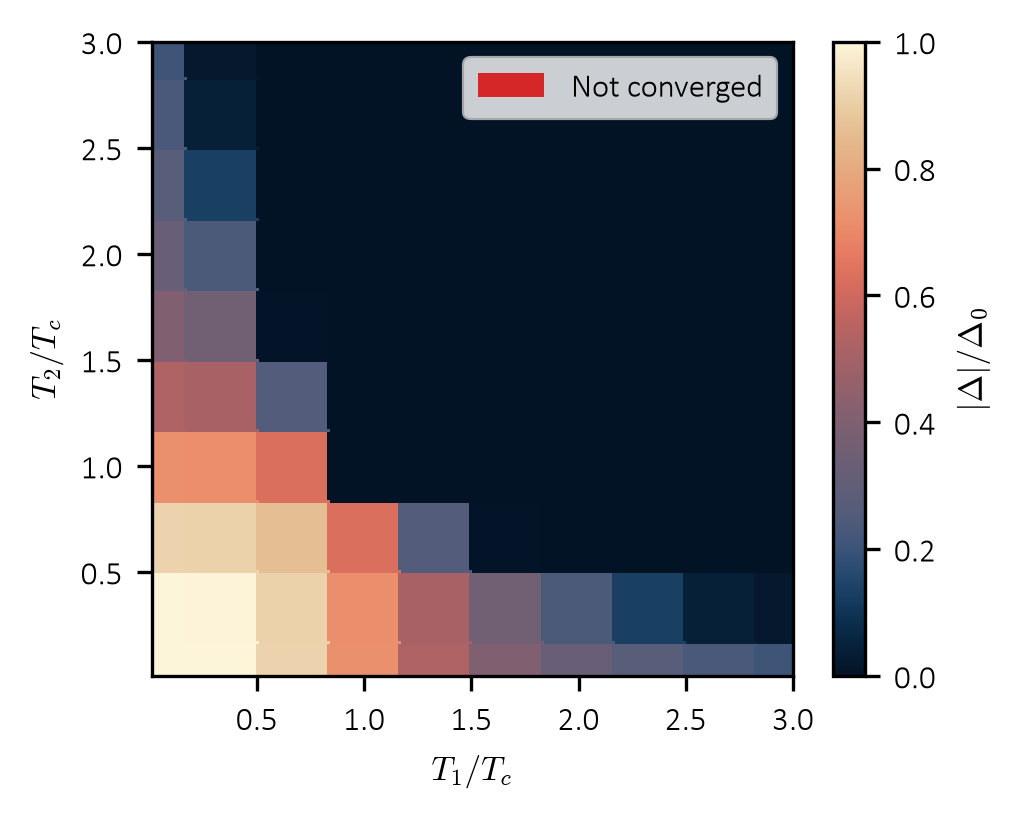

Plot maps: 100%|██████████| 2/2 [00:00<00:00, 11.91it/s]


In [24]:
dv = da / d0
vm = max(1.0, float(np.nanmax(dv)))

for marked in tqdm((False, True), desc="Plot maps"):
    h = 0.8
    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))
    cm = cmaps.lipari.copy()

    if marked:
        cm.set_bad("#d62728", alpha=1.0)
        z = np.ma.masked_invalid(np.ma.masked_where(~ok, dv))
    else:
        z = dv

    im = ax.pcolormesh(
        t1a / tc, t2a / tc, z,
        shading="auto", cmap=cm, vmin=0.0, vmax=vm,
    )
    im.set_edgecolor("face")

    ax.set_xlim(t1a[0] / tc, t1a[-1] / tc)
    ax.set_ylim(t2a[0] / tc, t2a[-1] / tc)
    ax.set_xlabel(r"$T_1/T_c$")
    ax.set_ylabel(r"$T_2/T_c$")

    if marked:
        ax.legend(
            handles=[Patch(facecolor="#d62728", label="Not converged")],
            loc="upper right",
        )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"$|\Delta|/\Delta_0$", rotation=90, labelpad=5)

    plt.tight_layout()
    plt.show()